In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

import seaborn as sns

In [15]:
df_all = pd.read_csv(r"X:\Personnel\MaryBeth\OpenScope\001568\results\results_all-probes_filtered-r2-0.50_20260330_111143\all_mice_all_probes_results.csv")

In [16]:
print(df_all.columns.tolist())

['mouse_name', 'probe', 'unit_id', 'rf', 'pref_ori', 'ori_responses', 'pref_tf', 'pref_tf_nested', 'pref_tf_gaussian', 'tf_responses', 'pref_sf', 'pref_sf_nested', 'pref_sf_gaussian', 'sf_responses', 'osi_dg', 'osi_dg_nested', 'osi_dg_gaussian', 'dsi_dg', 'dsi_dg_nested', 'dsi_dg_gaussian', 'peak_dff_dg', 'rf_x_center', 'rf_y_center', 'rf_r_squared', 'r_squared_gaussian', 'snr', 'rf_fwhm_deg', 'rf_size_deg', 'rf_sigma_x_deg', 'rf_sigma_y_deg', 'r_squared_filter']


In [17]:
X_discrete = df_all[['pref_ori', 'pref_tf', 'pref_sf', 'osi_dg']]
X_discrete_nested = df_all[['pref_ori', 'pref_tf_nested', 'pref_sf_nested', 'osi_dg']]
X_continuous = df_all[['pref_ori', 'pref_tf_gaussian', 'pref_sf_gaussian', 'osi_dg']]


# X = df_all[['snr']]

In [18]:
# Discrete options for each column
discrete_options = {
    'pref_ori': X_discrete['pref_ori'].dropna().unique(),
    'pref_tf': X_discrete['pref_tf'].dropna().unique(),
    'pref_sf': X_discrete['pref_sf'].dropna().unique(),
    'osi_dg': X_discrete['osi_dg'].dropna().unique(),
}

def snap_to_closest(value, options):
    if np.isnan(value):
        return np.nan
    return min(options, key=lambda x: abs(x - value))

X_snapped = X_continuous.copy()
X_snapped['pref_ori'] = X_continuous['pref_ori'].apply(
    lambda v: snap_to_closest(v, discrete_options['pref_ori'])
)
X_snapped['pref_tf_gaussian'] = X_continuous['pref_tf_gaussian'].apply(
    lambda v: snap_to_closest(v, discrete_options['pref_tf'])
)
X_snapped['pref_sf_gaussian'] = X_continuous['pref_sf_gaussian'].apply(
    lambda v: snap_to_closest(v, discrete_options['pref_sf'])
)
X_snapped['osi_dg'] = X_continuous['osi_dg'].apply(
    lambda v: snap_to_closest(v, discrete_options['osi_dg'])
)

In [19]:
print(X_snapped[:5])
print(X_continuous[:5])

   pref_ori  pref_tf_gaussian  pref_sf_gaussian    osi_dg
0      90.0               4.0              0.02  0.178672
1     135.0               4.0              0.16  0.324190
2      45.0               1.0              0.08  0.319438
3       0.0              15.0              0.08  0.112864
4      45.0               1.0              0.04  0.142857
   pref_ori  pref_tf_gaussian  pref_sf_gaussian    osi_dg
0      90.0          5.718947          0.024232  0.178672
1     135.0          3.029904          0.159948  0.324190
2      45.0          1.000000          0.104016  0.319438
3       0.0         15.000000          0.061084  0.112864
4      45.0          1.000000          0.039962  0.142857


In [20]:
X = X_snapped
#X = X_discrete
#X = X_discrete_nested

mask = X['osi_dg'].notna()
X=X[mask]
masked = True

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X.head())

rf_x_center = df_all['rf_x_center']-df_all['rf_x_center'].min()
rf_y_center = df_all['rf_y_center']-df_all['rf_y_center'].min()

block_size = 10

df_all['x_block'] = (rf_x_center // block_size).astype(int)
df_all['y_block'] = (rf_y_center // block_size).astype(int)

df_all['location'] = df_all['x_block'].astype(str) + '_' + df_all['y_block'].astype(str)

y = df_all['location']
if masked: 
    y=y[mask]

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# y_test = y_train 
# X_test = X_train

#print(y.unique())

   pref_ori  pref_tf_gaussian  pref_sf_gaussian    osi_dg
0      90.0               4.0              0.02  0.178672
1     135.0               4.0              0.16  0.324190
2      45.0               1.0              0.08  0.319438
3       0.0              15.0              0.08  0.112864
4      45.0               1.0              0.04  0.142857


# Support Vector Machine

In [22]:
svm = SVC(kernel='rbf', C=10000) #(kernel='linear')
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

         0_0       0.00      0.00      0.00        15
         0_1       0.11      0.11      0.11        36
         0_2       0.13      0.50      0.21        84
         0_3       0.00      0.00      0.00        32
         0_4       0.05      0.06      0.05        33
         0_5       0.09      0.12      0.10        42
         0_6       0.00      0.00      0.00         8
         0_7       0.14      0.06      0.08        17
         0_8       0.00      0.00      0.00         7
         1_0       0.00      0.00      0.00        17
         1_1       0.00      0.00      0.00        26
         1_2       0.00      0.00      0.00        18
         1_3       0.00      0.00      0.00         9
         1_4       0.04      0.05      0.04        21
         1_5       0.00      0.00      0.00        29
         1_6       0.00      0.00      0.00        13
         1_7       0.00      0.00      0.00        31
         1_8       0.00    

c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

['precision', 'recall', 'f1-score', 'support']


c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

<AxesSubplot: >

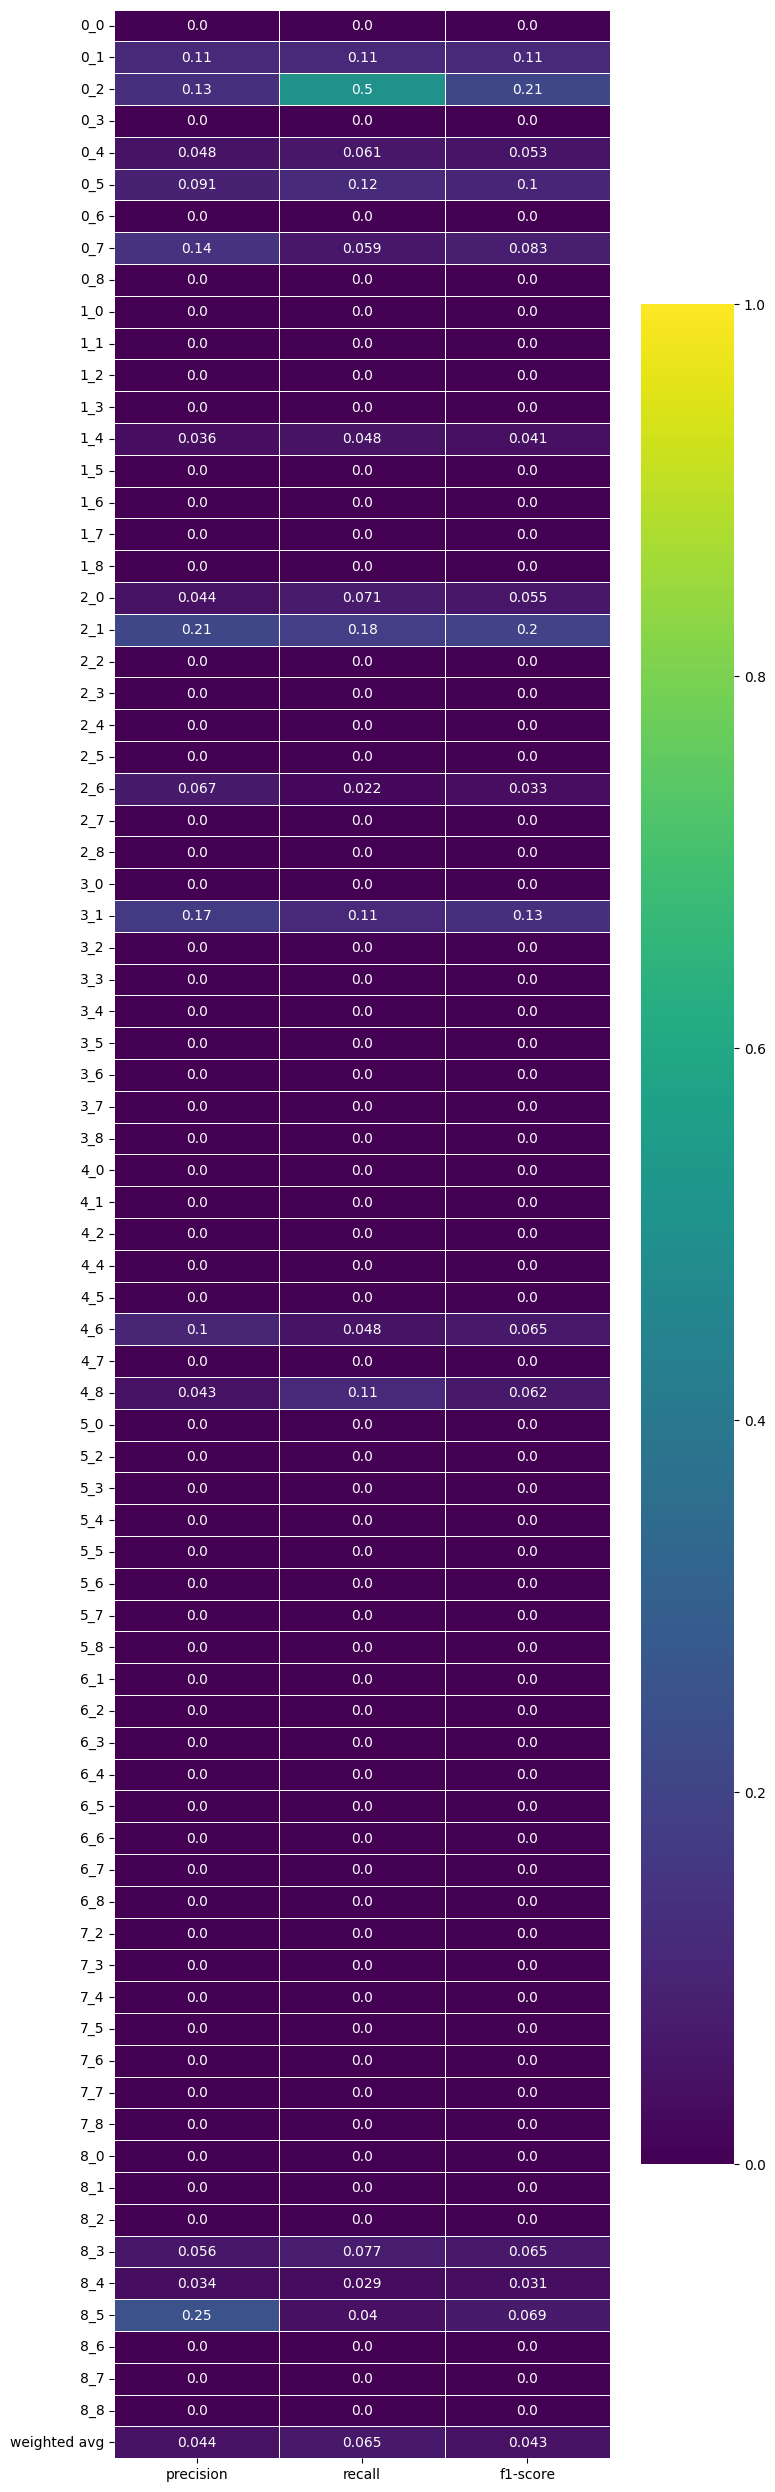

In [23]:
report = classification_report(y_test, y_pred, output_dict = True)
df_report = pd.DataFrame(report).T

print(df_report.columns.tolist())
df_report=df_report.drop(index=['accuracy', 'macro avg'])

fig, ax = plt.subplots(figsize=(8, len(df_report) *0.4 + 1))
sns.heatmap(df_report [['precision', 'recall', 'f1-score']],
            annot = True, fmt = '.2', cmap='viridis',
            linewidth=0.5, ax=ax, vmin=0, vmax=1)



## Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=20, random_state=42)
rf_model.fit(X_train, y_train)
y_rf_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_rf_pred))
print(confusion_matrix(y_test, y_rf_pred))


              precision    recall  f1-score   support

         0_0       0.00      0.00      0.00        15
         0_1       0.06      0.06      0.06        36
         0_2       0.10      0.10      0.10        84
         0_3       0.07      0.09      0.08        32
         0_4       0.02      0.03      0.02        33
         0_5       0.00      0.00      0.00        42
         0_6       0.00      0.00      0.00         8
         0_7       0.10      0.06      0.07        17
         0_8       0.00      0.00      0.00         7
         1_0       0.04      0.06      0.05        17
         1_1       0.00      0.00      0.00        26
         1_2       0.00      0.00      0.00        18
         1_3       0.00      0.00      0.00         9
         1_4       0.06      0.05      0.05        21
         1_5       0.00      0.00      0.00        29
         1_6       0.00      0.00      0.00        13
         1_7       0.19      0.10      0.13        31
         1_8       0.00    

c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

['precision', 'recall', 'f1-score', 'support']


<AxesSubplot: >

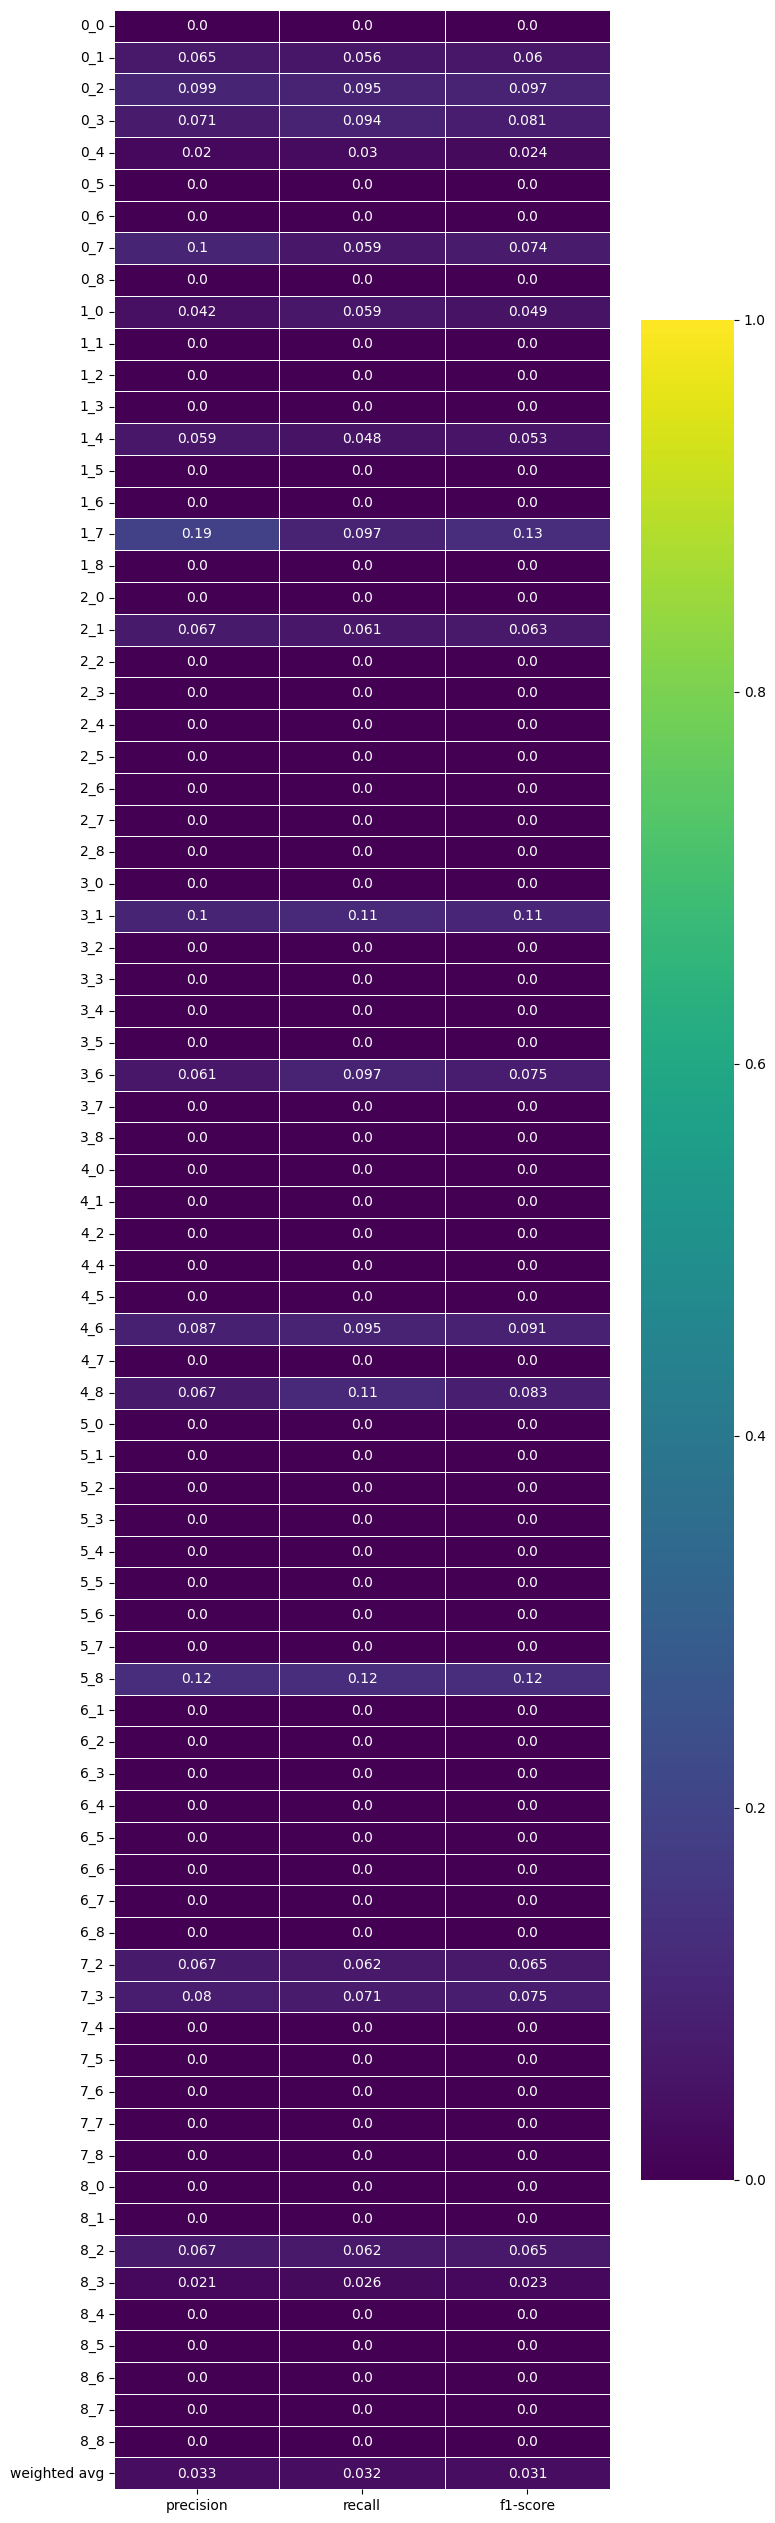

In [25]:
report = classification_report(y_test, y_rf_pred, output_dict = True)
df_report = pd.DataFrame(report).T

print(df_report.columns.tolist())
df_report=df_report.drop(index=['accuracy', 'macro avg'])

fig, ax = plt.subplots(figsize=(8, len(df_report) *0.4 + 1))
sns.heatmap(df_report [['precision', 'recall', 'f1-score']],
            annot = True, fmt = '.2', cmap='viridis',
            linewidth=0.5, ax=ax, vmin=0, vmax=1)



# Visualization for both

c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

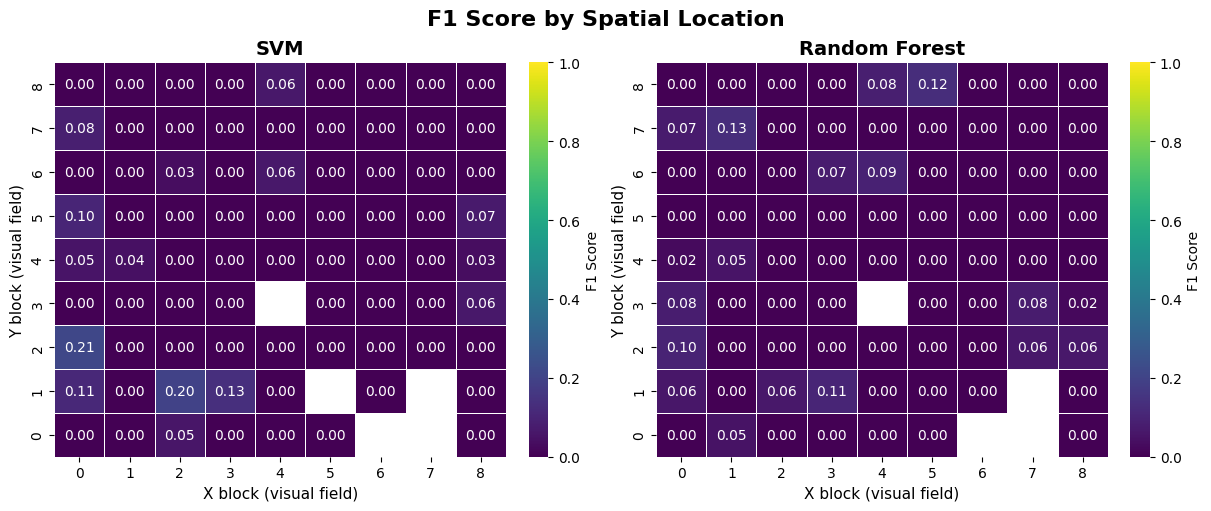

Saved to spatial_f1_grid.png


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# --- After running your models, generate reports for both ---
# Assumes y_test, y_pred (SVM), y_rf_pred (RF) are already defined

def make_spatial_f1_grid(y_test, y_pred, title):
    report = classification_report(y_test, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).T.drop(index=['accuracy', 'macro avg', 'weighted avg'])
    df_report.index.name = 'location'
    df_report = df_report.reset_index()

    # Parse x_block and y_block from location label (e.g. "3_5")
    df_report['x_block'] = df_report['location'].apply(lambda l: int(l.split('_')[0]))
    df_report['y_block'] = df_report['location'].apply(lambda l: int(l.split('_')[1]))

    # Pivot into a 2D grid
    grid = df_report.pivot(index='y_block', columns='x_block', values='f1-score')

    return grid, title


# Build grids for both models
grid_svm, title_svm = make_spatial_f1_grid(y_test, y_pred, 'SVM')
grid_rf,  title_rf  = make_spatial_f1_grid(y_test, y_rf_pred, 'Random Forest')

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for ax, grid, title in zip(axes, [grid_svm, grid_rf], [title_svm, title_rf]):
    sns.heatmap(
        grid,
        ax=ax,
        cmap='viridis',
        vmin=0, vmax=1,
        annot=True, fmt='.2f',
        linewidths=0.5,
        cbar_kws={'label': 'F1 Score'}
    )
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('X block (visual field)', fontsize=11)
    ax.set_ylabel('Y block (visual field)', fontsize=11)
    ax.invert_yaxis()  # so y increases upward like visual space

plt.suptitle('F1 Score by Spatial Location', fontsize=16, fontweight='bold')
plt.savefig('spatial_f1_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to spatial_f1_grid.png")